## Uncertainties in position reconstruction with the XENON1T Detector

XENON1T was a dark matter detector that I worked on for my PhD thesis. One of our data analysis problems was reconstructing the positions of particle interactions in the detector.

In this notebook you're going to train a neural network to do that reconstruction.

### Set up simulator

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import configparser
from scipy import stats
from sklearn.metrics import roc_curve, auc

This downloads the detector configuration, specifically, the positions of the light sensors (photomultipliers or PMTs).

In [2]:
!curl -O https://raw.githubusercontent.com/XENON1T/pax/refs/heads/master/pax/config/XENON1T.ini
config = configparser.ConfigParser()
config.read('XENON1T.ini')
pmt_config = eval(config['DEFAULT']['pmts'])
pmt_positions = np.array([(x['position']['x'], x['position']['y'])
                           for x in pmt_config if x.get('array', '') == 'top'])
tpc_radius = 47.9

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 303.3k 100 303.3k   0      0 982.5k      0                              0
100 303.3k 100 303.3k   0      0 981.8k      0                              0
100 303.3k 100 303.3k   0      0 981.1k      0                              0


Set up a simple simulator to create fake observed XENON1T patterns. We have a rather more intricate simulation, but this is enough for this exercise.

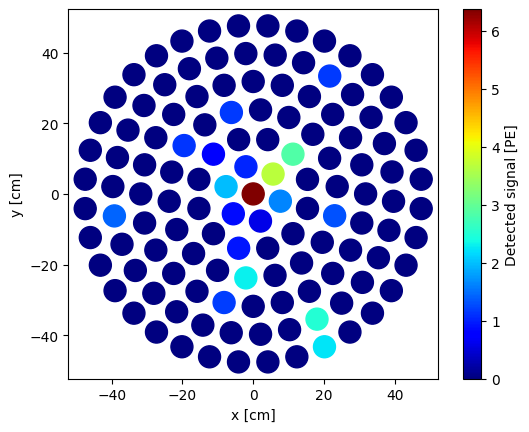

In [4]:
def mean_response(xy):
    """Return normalized mean response of PMTs to light emission at xy"""
    a = -2.7e-5
    b = 3.6e-3
    i0 = 0.290
    d = 12.13
    p = 2.35
    # Compute distance from xy to pmt position
    # xy has shape (positions, 2)
    # pmt_positions has shape (pmts, 2)
    # Output should have shape (positions, pmts)
    rho = np.linalg.norm(xy[:, None, :] - pmt_positions[None, :, :], axis=2)
    raw_lce = i0 * (1-b) / (1 + (rho/d)**2)**p + a * rho + b
    # Normalize to 1
    return raw_lce / np.sum(raw_lce, axis=1)[:, None]

def simulate_signal(xy, photons=10_000):
    """Simulate a signal where an average number of photons are detected by PMTs at xy"""
    lce = mean_response(xy)
    # Random photon detection
    photons_detected = np.random.poisson(photons * lce)
    # Double photoelectron emission
    pe_detected = photons_detected + np.random.binomial(photons_detected, 0.2)
    # Gaussian smearing
    return np.random.normal(pe_detected, 0.3 * np.sqrt(pe_detected))

def plot_signal(signal):
    """Plot the signal detected by the PMTs"""
    plt.scatter(*pmt_positions.T, c=signal, cmap='jet', s=250, vmin=0)
    plt.colorbar(label='Detected signal [PE]')
    plt.gca().set_aspect('equal')
    plt.xlabel('x [cm]')
    plt.ylabel('y [cm]')

plot_signal(simulate_signal(np.array([[0, 0]]), photons=30).sum(axis=0))

In [38]:
#Determining the chi squared statistic
def chi_squared(observed, expected):
    """Calculate the chi-squared statistic for observed vs expected signals"""
    # Avoid division by zero by using np.where, which replaces any zeroes with a small number
    expected = np.where(expected == 0, 1e-6, expected) 
    return np.sum((observed - expected) ** 2 / expected)

print(chi_squared(simulate_signal(np.array([[0, 0], [0,0]])), mean_response(np.array([[0, 0]]))))

print(chi_squared(simulate_signal(np.array([[0, 0], [1, 1]])), mean_response(np.array([[0, 0]]))))

print(chi_squared(simulate_signal(np.array([[0, 0], [2, 2]])), mean_response(np.array([[0, 0]]))))



302023991.99388915
297393802.8685205
301064909.1555614


The consistency between the observed and expected S2 pattern intensity distribution on the top
PMT array is quantified by a χ2 goodness-of-fit test
and outlier events are rejected. The expected light
distribution is derived from a data-driven map built
on a neural network fed with high quality 83mKr
calibration data. The 99% quantile of the χ2 dis-
tribution as a function of S2 area is used as the se-
lection criterion. This selection mainly suppresses
the pileup of delayed electron signals, double scat-
ters, and mis-reconstructed events. Due to a loss of
accuracy in the data-driven map for large S2 areas,
this criterion is limited for events with S2s smaller
than 3×104 PE.

In [51]:
#Performing goodness of fit test for iterations of single scatter and double scatter events
#at (0,0) and (1,1) and plotting roc curve
def chi_squared_test(observed, expected):
    """Perform a chi-squared goodness of fit test and return the p-value"""
    # Calculate the chi-squared statistic
    chi2_stat = chi_squared(observed, expected)
    # Degrees of freedom is number of PMTs minus 1
    dof = len(expected) - 1
    # Calculate the p-value using the survival function (1 - CDF) of the chi-squared distribution
    p_value = stats.chi2.sf(chi2_stat, dof)
    return p_value

def binary_classification_test(num_trials=1000):
    """Perform a binary classification test to distinguish single vs double scatter events"""
    single_p_values = []
    double_p_values = []
    
    for _ in range(num_trials):
        # Simulate single scatter event
        single_signal = simulate_signal(np.array([[0, 0]]), photons=30).sum(axis=0)
        expected_single = mean_response(np.array([[0, 0]]))[0]
        single_p_values.append(chi_squared_test(single_signal, expected_single))
        
        # Simulate double scatter event
        double_signal = simulate_signal(np.array([[0, 0], [1, 1]]), photons=30).sum(axis=0)
        expected_double = mean_response(np.array([[0, 0], [1, 1]])).sum(axis=0)
        double_p_values.append(chi_squared_test(double_signal, expected_double))
    
    return single_p_values, double_p_values

print(binary_classification_test())






([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

Building chi-squared threshold from calibration throws...
  Chi-squared threshold at 99th percentile: 239.16


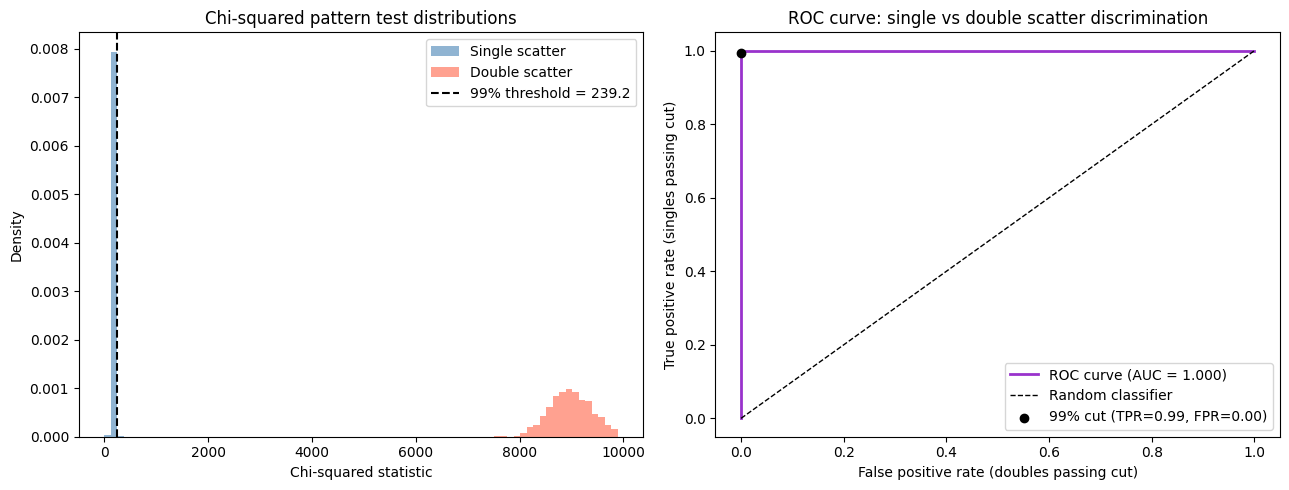

In [52]:
def chi_squared_gof(observed, expected_fractions, total_photons):
    """
    Perform a chi-squared goodness-of-fit test comparing observed PMT signals
    to the expected light distribution pattern.
    
    Parameters
    ----------
    observed          : array (n_pmts,)  -- measured signal in PE per PMT
    expected_fractions: array (n_pmts,)  -- normalised expected light fractions (sums to 1)
    total_photons     : float            -- total observed signal (S2 area) in PE
    
    Returns
    -------
    chi2_stat : float  -- chi-squared statistic
    p_value   : float  -- p-value (low = poor fit = likely not a single scatter)
    """
    # Scale normalised LCE fractions to expected absolute PE counts
    # This is what chi-squared requires: observed and expected in the same units
    expected_counts = expected_fractions * total_photons

    # Avoid division by zero for PMTs with negligible expected signal
    mask = expected_counts > 0
    chi2_stat = np.sum(
        (observed[mask] - expected_counts[mask])**2 / expected_counts[mask]
    )

    # Degrees of freedom: number of contributing PMTs minus 1
    # (minus 1 because the total is constrained to sum to total_photons)
    dof = np.sum(mask) - 1

    p_value = stats.chi2.sf(chi2_stat, dof)
    return chi2_stat, p_value


def get_chi2_threshold(position, total_photons, num_trials=5000, quantile=0.99):
    """
    Build a data-driven chi-squared threshold at a given quantile by simulating
    many single-scatter events at the same position and S2 area.
    
    This mirrors the experimental approach: a map of chi-squared quantiles is
    built from calibration data (83mKr in the paper) as a function of S2 area,
    and events exceeding the 99th percentile are rejected as outliers.

    Parameters
    ----------
    position      : array (1, 2)  -- source position in cm
    total_photons : int           -- S2 area in PE (determines the quantile curve)
    num_trials    : int           -- number of calibration-like throws
    quantile      : float         -- rejection threshold quantile (default 0.99)

    Returns
    -------
    threshold : float  -- chi-squared value at the requested quantile
    """
    expected_fractions = mean_response(position)[0]
    chi2_values = []

    for _ in range(num_trials):
        signal = simulate_signal(position, photons=total_photons)[0]
        chi2_stat, _ = chi_squared_gof(signal, expected_fractions, signal.sum())
        chi2_values.append(chi2_stat)

    return np.quantile(chi2_values, quantile)


def classify_event(signal, position, total_photons, threshold):
    """
    Classify an event as single scatter (pass) or outlier/double scatter (reject)
    using the chi-squared pattern test against the expected single-scatter LCE map.

    Parameters
    ----------
    signal        : array (n_pmts,)  -- observed PMT signals in PE
    position      : array (1, 2)     -- reconstructed event position
    total_photons : float            -- S2 area (sum of signal)
    threshold     : float            -- chi-squared cut value from get_chi2_threshold

    Returns
    -------
    chi2_stat : float
    passed    : bool  -- True if event passes (looks like single scatter)
    """
    expected_fractions = mean_response(position)[0]
    chi2_stat, _ = chi_squared_gof(signal, expected_fractions, total_photons)
    return chi2_stat, chi2_stat <= threshold


def run_classification_trial(
    single_position=np.array([[0, 0]]),
    double_positions=np.array([[0, 0], [0.00001, 0.00001]]),
    photons=10000,
    num_trials=1000,
    quantile=0.99
):
    """
    Simulate single and double scatter events, apply the chi-squared pattern
    test, and return chi-squared statistics for ROC curve construction.

    The hypothesis being tested: does the observed PMT light pattern match
    the expected pattern for a single scatter at the reconstructed position?
    Double scatters produce light from two locations simultaneously, creating
    a distorted pattern that should fail the test.

    Parameters
    ----------
    single_position  : array (1, 2)   -- position of single scatter events
    double_positions : array (2, 2)   -- positions of the two scatters
    photons          : int            -- total S2 area in PE
    num_trials       : int            -- number of events to simulate per class
    quantile         : float          -- chi-squared threshold quantile

    Returns
    -------
    single_chi2s : array  -- chi-squared values for single scatter events
    double_chi2s : array  -- chi-squared values for double scatter events
    threshold    : float  -- the chi-squared cut value used
    """
    # Build the data-driven threshold from single-scatter calibration throws
    # (analogous to building the 83mKr LCE map in the experiment)
    print("Building chi-squared threshold from calibration throws...")
    threshold = get_chi2_threshold(single_position, photons, quantile=quantile)
    print(f"  Chi-squared threshold at {quantile*100:.0f}th percentile: {threshold:.2f}")

    single_chi2s = []
    double_chi2s = []

    for _ in range(num_trials):
        # --- Single scatter: one interaction vertex, clean LCE pattern ---
        single_signal = simulate_signal(single_position, photons=photons)[0]
        chi2_stat, _ = classify_event(
            single_signal, single_position, single_signal.sum(), threshold
        )
        single_chi2s.append(chi2_stat)

        # --- Double scatter: two vertices, distorted combined LCE pattern ---
        # Photons split evenly between the two sites
        double_signal = simulate_signal(double_positions, photons=photons // 2).sum(axis=0)
        chi2_stat, _ = classify_event(
            double_signal, single_position, double_signal.sum(), threshold
        )
        double_chi2s.append(chi2_stat)

    return np.array(single_chi2s), np.array(double_chi2s), threshold


def plot_results(single_chi2s, double_chi2s, threshold):
    """
    Plot (1) the chi-squared distributions for both event classes with the
    threshold marked, and (2) the ROC curve for the classifier.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # --- Left: chi-squared distributions ---
    ax = axes[0]
    bins = np.linspace(0, np.percentile(np.concatenate([single_chi2s, double_chi2s]), 99), 80)
    ax.hist(single_chi2s, bins=bins, alpha=0.6, label='Single scatter', color='steelblue', density=True)
    ax.hist(double_chi2s, bins=bins, alpha=0.6, label='Double scatter', color='tomato', density=True)
    ax.axvline(threshold, color='black', linestyle='--', label=f'99% threshold = {threshold:.1f}')
    ax.set_xlabel('Chi-squared statistic')
    ax.set_ylabel('Density')
    ax.set_title('Chi-squared pattern test distributions')
    ax.legend()

    # --- Right: ROC curve ---
    # Label single scatter as positive class (1), double scatter as negative (0)
    # Higher chi-squared → more likely to be a double scatter → reject
    ax = axes[1]
    labels = np.concatenate([np.ones(len(single_chi2s)), np.zeros(len(double_chi2s))])
    scores  = np.concatenate([-single_chi2s, -double_chi2s])  # negate: low chi2 = more single-scatter-like
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color='darkorchid', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')

    # Mark the operating point corresponding to the 99% chi-squared threshold
    op_tpr = np.mean(single_chi2s <= threshold)   # fraction of singles that pass
    op_fpr = np.mean(double_chi2s <= threshold)   # fraction of doubles that wrongly pass
    ax.scatter(op_fpr, op_tpr, color='black', zorder=5,
               label=f'99% cut (TPR={op_tpr:.2f}, FPR={op_fpr:.2f})')

    ax.set_xlabel('False positive rate (doubles passing cut)')
    ax.set_ylabel('True positive rate (singles passing cut)')
    ax.set_title('ROC curve: single vs double scatter discrimination')
    ax.legend()

    plt.tight_layout()
    plt.show()


# --- Run the full analysis ---
single_chi2s, double_chi2s, threshold = run_classification_trial(
    single_position  = np.array([[0, 0]]),
    double_positions = np.array([[0, 0], [10, 10]]),
    photons  = 10_000,
    num_trials = 1000,
    quantile   = 0.99
)
plot_results(single_chi2s, double_chi2s, threshold)